In [21]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import datetime
from datetime import datetime

In [31]:
data =yf.download("AAPL", start="2024-1-1")

[*********************100%***********************]  1 of 1 completed


In [41]:
data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.903244,186.677052,182.169616,185.399112,82488700
2024-01-03,182.526230,184.140985,181.713894,182.496512,58414500
2024-01-04,180.208130,181.377083,179.187767,180.445875,71983600
2024-01-05,179.484940,181.050159,178.484394,180.287374,62379700
2024-01-08,183.823990,183.863624,179.801976,180.386452,59144500
...,...,...,...,...,...
2025-12-19,273.670013,274.600006,269.899994,272.149994,144632000
2025-12-22,270.970001,273.880005,270.510010,272.859985,36571800


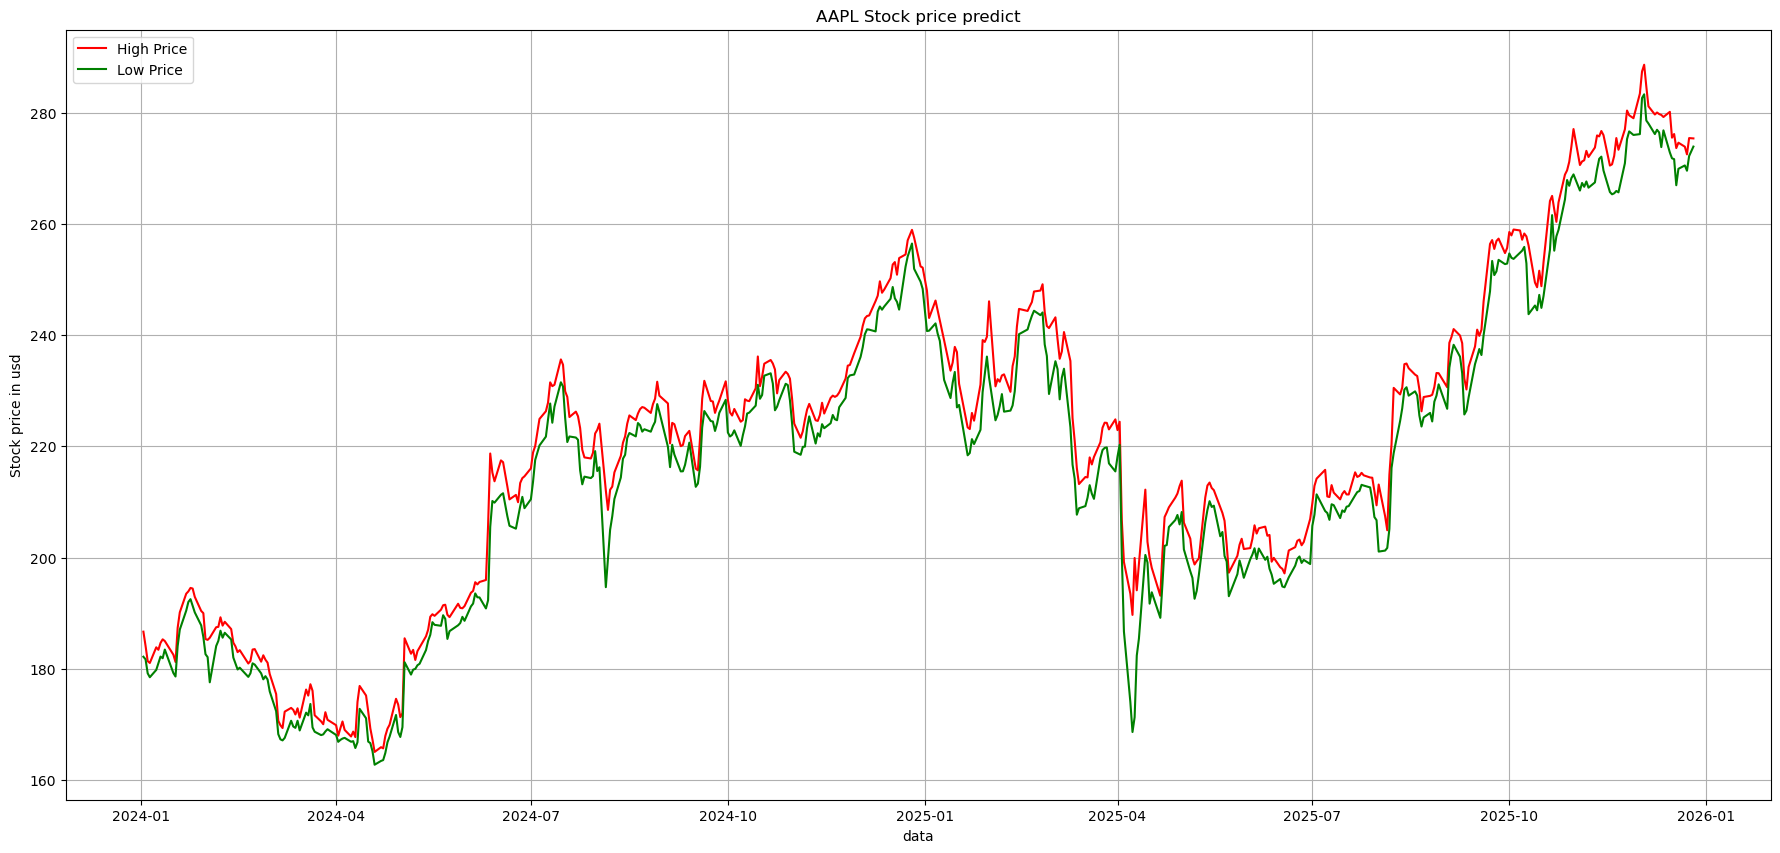

In [61]:
plt.figure(figsize=(22,10))
plt.plot(data.index, data['High'],label="High Price", color = "r")
plt.plot(data.index, data['Low'],label="Low Price", color = "g")

plt.title("AAPL Stock price predict")
plt.xlabel("data")
plt.ylabel("Stock price in usd")
plt.legend()
plt.grid(True)
plt.show()

# Classical Time Series Decomposition

In [66]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [68]:
decomposed_additive = seasonal_decompose(data["Close"], model="additive" ,period=30)

In [70]:
trend_additive = decomposed_additive.trend
seasonal_additive = decomposed_additive.seasonal
residual_additive = decomposed_additive.resid

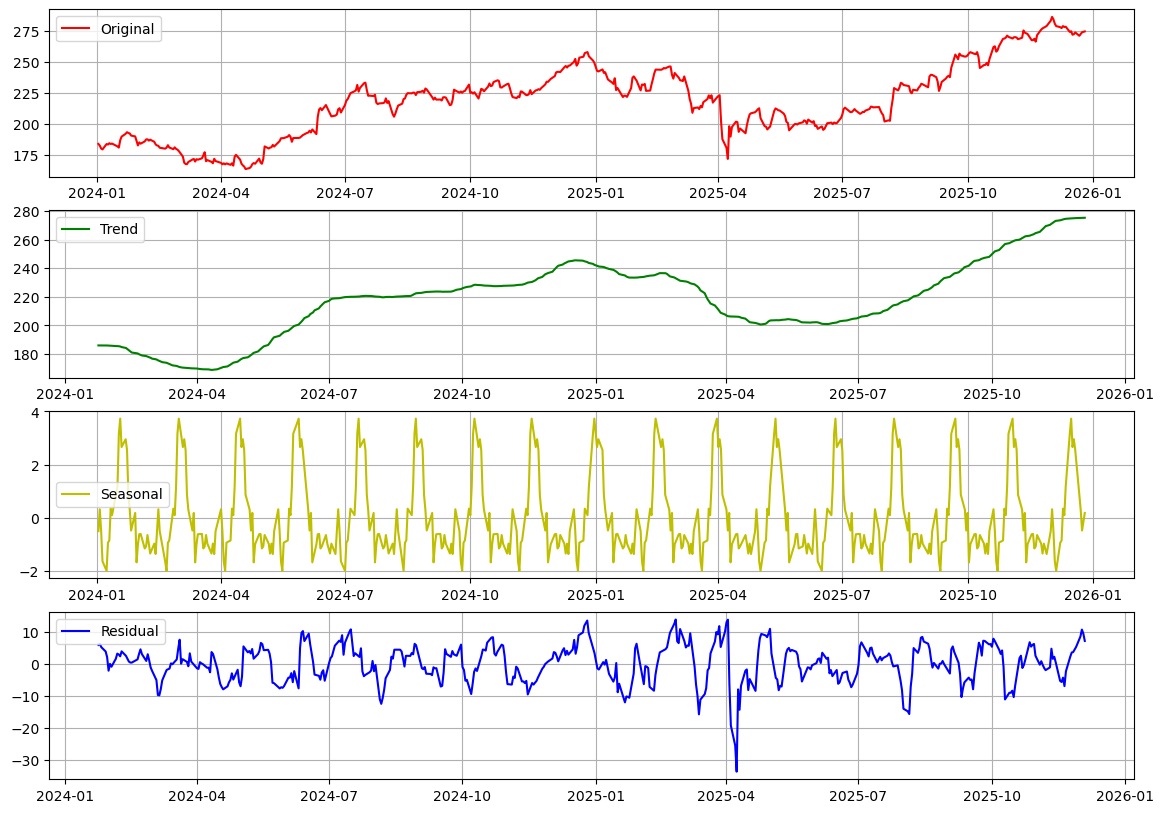

In [82]:
# Original Close price Data
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(data["Close"], label = "Original", color = "r")
plt.legend()
plt.grid(True)

# trend additive
plt.subplot(412)
plt.plot(trend_additive, label = "Trend", color = "g")
plt.legend()
plt.grid(True)

# seasonal_additive
plt.subplot(413)
plt.plot(seasonal_additive, label = "Seasonal" , color = "y")
plt.legend()
plt.grid(True)

# 
plt.subplot(414)
plt.plot(residual_additive, label = "Residual" , color = "b")
plt.legend()
plt.grid(True)
plt.show()


# STL DECOPOSITION

In [85]:
from statsmodels.tsa .seasonal import STL
stl = STL(data["Close"], period = 30)
result = stl.fit()

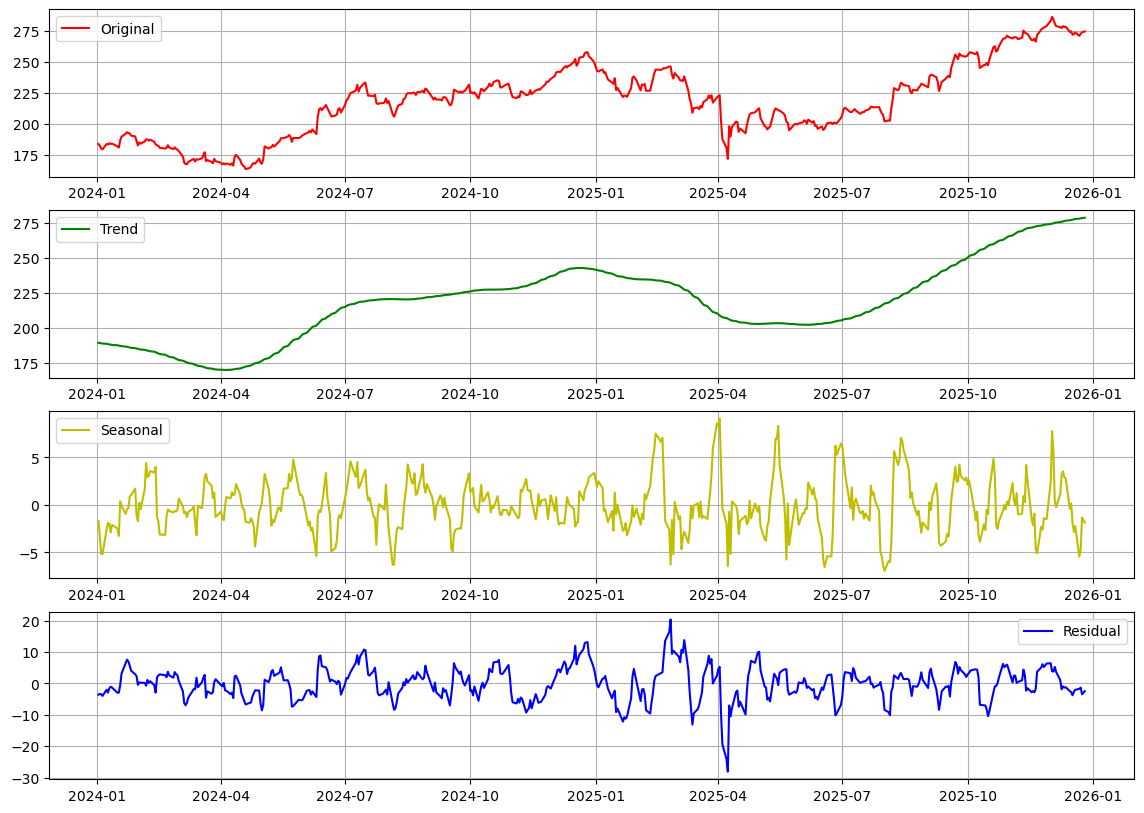

In [91]:
# Original Close price Data
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(result.observed, label = "Original", color = "r")
plt.legend()
plt.grid(True)

# trend additive 
plt.subplot(412)
plt.plot(result.trend, label = "Trend", color = "g")
plt.legend()
plt.grid(True)

# seasonal_additive
plt.subplot(413)
plt.plot(result.seasonal, label = "Seasonal" , color = "y")
plt.legend()
plt.grid(True)

# 
plt.subplot(414)
plt.plot(result.resid, label = "Residual" , color = "b")
plt.legend()
plt.grid(True)
plt.show()


# Time series Forecasting

# AR MODEL

In [95]:
data = yf.download("AAPL", start="2023-1-1")

[*********************100%***********************]  1 of 1 completed


In [107]:
# data["close"] ka diff jb kro to first nan ho jati hia aur is liye dropna kia
aapl_statinoray = data["Close"].diff().dropna()
# split the dataset into train[:718] rows  and test[30] rows
train_data,test_data = aapl_statinoray[:-30], aapl_statinoray[-30:]

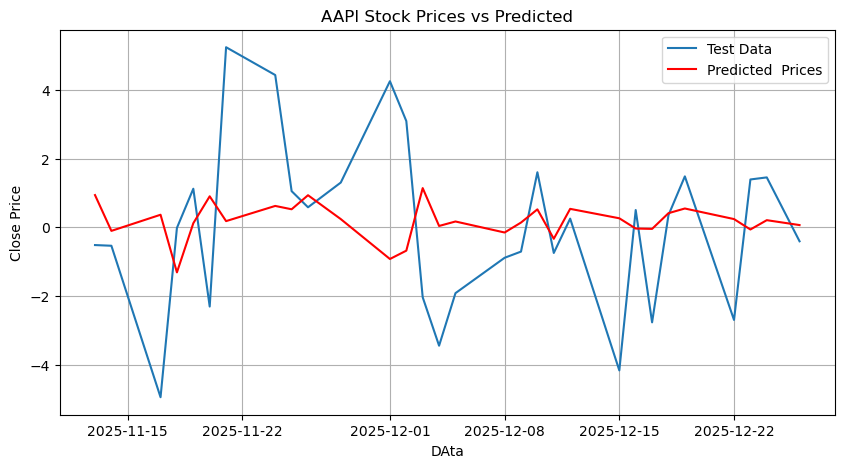

RMS : 1.41


In [159]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# fit the Autoagressive model (AR) to the model
model = AutoReg(train_data, lags=30) # leg predict 30 days
model_fit = model.fit()

# make prediction the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic = (False)
    
)

# plot the actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label = "Test Data")
plt.plot(test_data.index, predictions, color = "r", label = "Predicted  Prices")
plt.title("AAPl Stock Prices vs Predicted")
plt.xlabel("DAta")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

# ealuate model using mse 
rms = round(np.sqrt(mean_absolute_error(test_data, predictions)),2)
print("RMS :", rms)

# MA MOdel

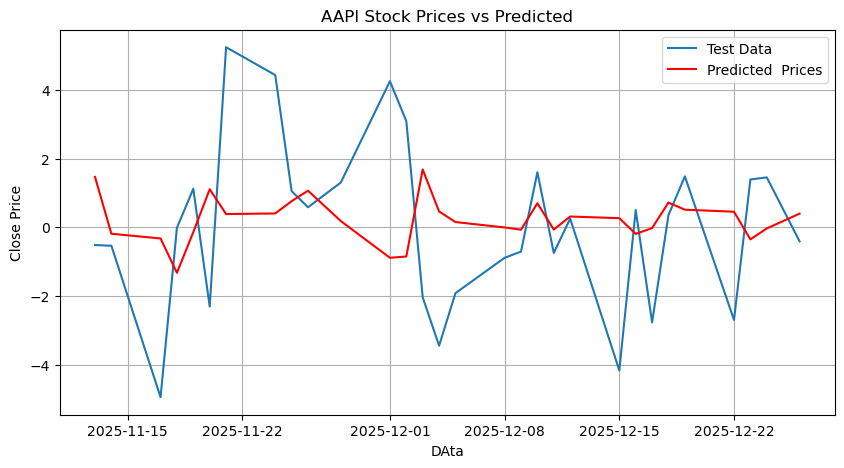

RMS : 1.44


In [166]:
from statsmodels.tsa.arima.model import ARIMA

# fit the Moving Average (MA) to the model
model = ARIMA(train_data, order=(0,0,30)) # leg predict 30 days (p,d,q)
model_fit = model.fit()

# make prediction the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic = (False)
    
)

# plot the actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label = "Test Data")
plt.plot(test_data.index, predictions, color = "r", label = "Predicted  Prices")
plt.title("AAPl Stock Prices vs Predicted")
plt.xlabel("DAta")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

# ealuate model using mse 
rms = round(np.sqrt(mean_absolute_error(test_data, predictions)),2)
print("RMS :", rms)

# ARMA MODEL

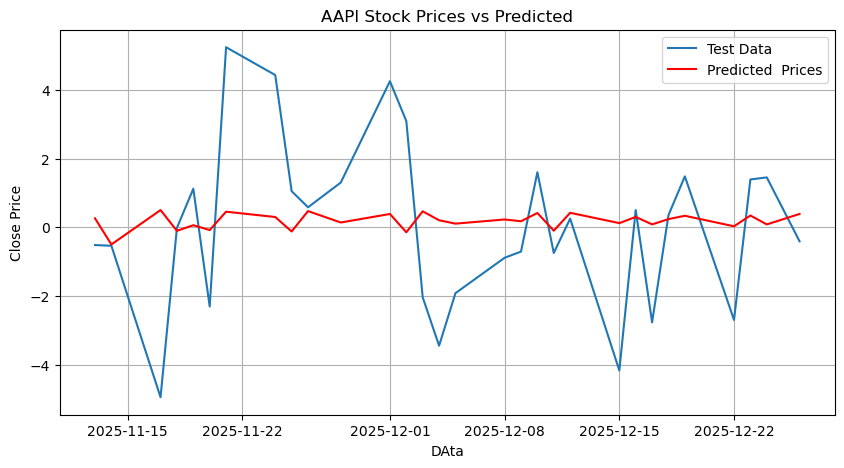

RMS : 1.35


In [169]:
from statsmodels.tsa.arima.model import ARIMA

# fit the Moving Average (MA) to the model
model = ARIMA(train_data, order=(7,0,7)) # leg predict 30 days (p,d,q)
model_fit = model.fit()

# make prediction the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic = (False)
    
)

# plot the actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label = "Test Data")
plt.plot(test_data.index, predictions, color = "r", label = "Predicted  Prices")
plt.title("AAPl Stock Prices vs Predicted")
plt.xlabel("DAta")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

# ealuate model using mse 
rms = round(np.sqrt(mean_absolute_error(test_data, predictions)),2)
print("RMS :", rms)

# MULTIVARITE (DO DATA KO KRNA USE AIK SATH)

# VECTOR MODELS

In [191]:
tsla_data = yf.download("TSLA", start="2023-1-1")
data['TSLA_CLOSE']=tsla_data['Close']
data["AAPL_CLOSE"] = data["Close"].shift()
data.dropna(inplace=True)

from statsmodels.tsa.stattools import grangercausalitytests
# perfrom grangercausalitytests Test

grangercausalitytests(data[['AAPL_CLOSE','TSLA_CLOSE']].dropna(), maxlag=[14])
print()


[*********************100%***********************]  1 of 1 completed


Granger Causality
number of lags (no zero) 14
ssr based F test:         F=10.3593 , p=0.0000  , df_denom=705, df_num=14
ssr based chi2 test:   chi2=150.9954, p=0.0000  , df=14
likelihood ratio test: chi2=137.3119, p=0.0000  , df=14
parameter F test:         F=10.3593 , p=0.0000  , df_denom=705, df_num=14



In [197]:
multi_data = data[['AAPL_CLOSE','TSLA_CLOSE']].diff().dropna()


In [207]:
train_data = multi_data[:-14]

In [217]:
test_data = multi_data[-14:]

# MULTIARITE MODEL SHIFT

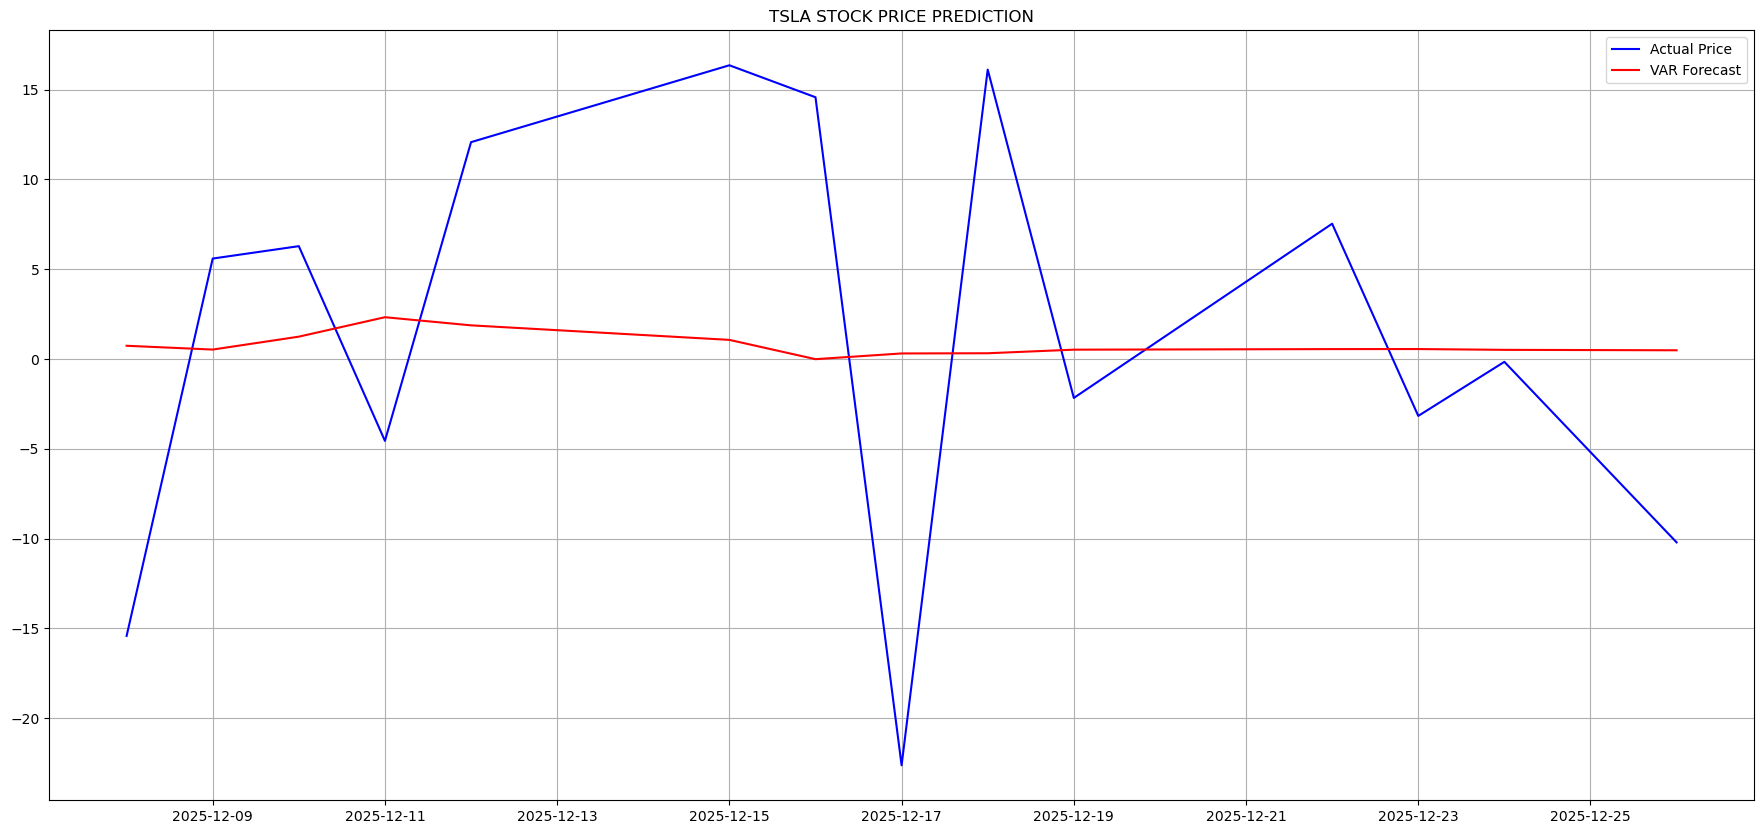

RMS : 3.12


In [242]:
from statsmodels.tsa.api import VAR
import pandas as pd
# Build VAR model
model = VAR(train_data)
results = model.fit(maxlags=7)  # lag order = 7

# Forecast next 10 steps
forecast = results.forecast(train_data.values[-7:], steps=len(test_data))

# data frame
forecast = pd.DataFrame(forecast, index=test_data.index, columns=test_data.columns)

# Plot
plt.figure(figsize=(22,10))
plt.plot(test_data.index, test_data["TSLA_CLOSE"], label='Actual Price', color="blue")
plt.plot(test_data.index,forecast["TSLA_CLOSE"], label='VAR Forecast', color='red')
plt.legend()
plt.title('TSLA STOCK PRICE PREDICTION')
plt.grid(True)
plt.show()

rms = round(np.sqrt(mean_absolute_error(test_data["TSLA_CLOSE"], forecast["TSLA_CLOSE"])),2)
print("RMS :", rms)

# bhot sai model kr skte hai 
# 1: VARMA 